# Tutorial #2: Visualization

# Visualizing factors using the scFO plotting suite

In this tutorial, we will show how to visualize factor annotations using a pre-built scFO object from our GBM atlas.

# Import packages

In [1]:
import pandas as pd
import numpy as np
import anndata as ad
import scanpy as sc
import muon as mu
import re
import gseapy as gp
import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import scfo

# Visualizing factor annotations

scFO provides a few simple plotting functions to visualize modality enrichment and feature loadings. Additionally, helpers are available to export any modality's enrichment/loadings into DataFrame format for custom visualization. First, we load the `ontology` object:

In [2]:
ontology = mu.read_h5mu('scfo_output/scfo_mofa_gbm.h5mu')

First, to view a given factor's gene weights:

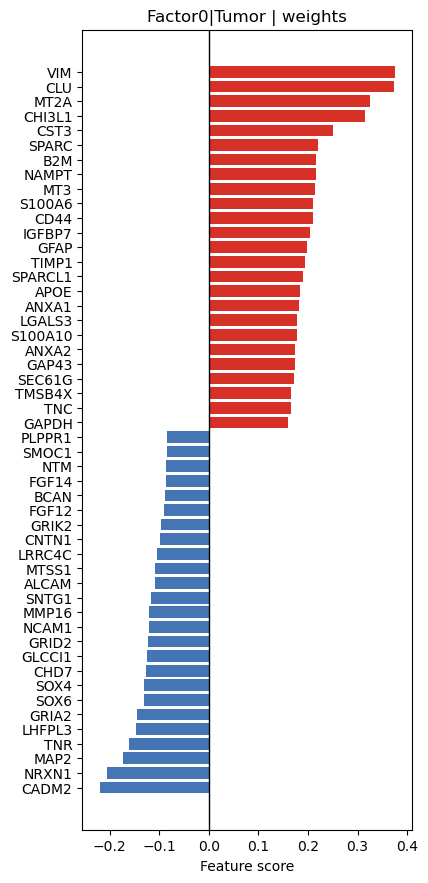

In [3]:
factor = 'Factor0|Tumor'
mod = 'weights'

fig, ax = scfo.plot_factor_top_features(
    ontology,
    factor=factor,
    modality=mod,
    n_pos=25,
    n_neg = 25,
    figsize = (3.3, 8),
    path = 'Figures/'+factor+'_'+mod+'.svg'
)

To view enrichment scores for a given modality, simply use the same function:

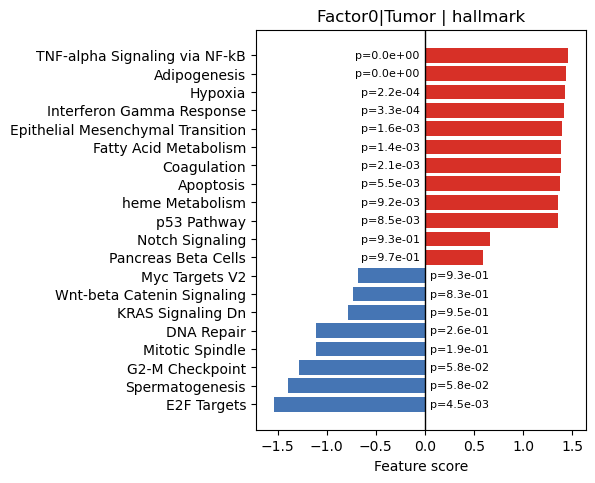

In [4]:
factor = 'Factor0|Tumor'
mod = 'hallmark'

fig, ax = scfo.plot_factor_top_features(
    ontology,
    factor=factor,
    modality=mod,
    n_pos=10,
    n_neg = 10,
    figsize = (3.3, 4),
    path = 'Figures/'+factor+'_'+mod+'.svg'
)

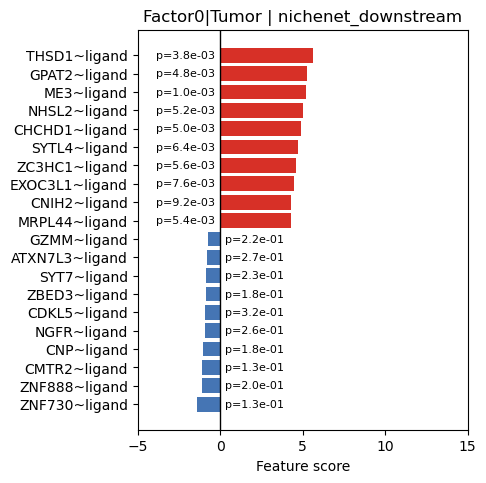

In [5]:
factor = 'Factor0|Tumor'
mod = 'nichenet_downstream'

fig, ax = scfo.plot_factor_top_features(
    ontology,
    factor=factor,
    modality=mod,
    n_pos=10,
    n_neg = 10,
    figsize = (3.3, 4),
    xlim = (-5, 15),
    path = 'Figures/'+factor+'_'+mod+'.svg'
)

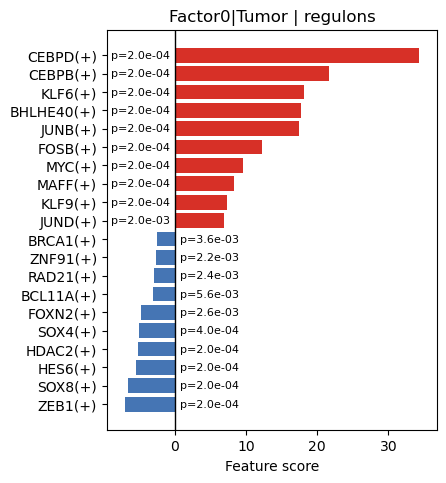

In [6]:
factor = 'Factor0|Tumor'
mod = 'regulons'

fig, ax = scfo.plot_factor_top_features(
    ontology,
    factor=factor,
    modality=mod,
    n_pos=10,
    n_neg = 10,
    figsize = (3.3, 4),
    path = 'Figures/'+factor+'_'+mod+'.svg'
)

To visualize a modality's gene loadings (stored in `.varm['feature_loadings']` for each modality):

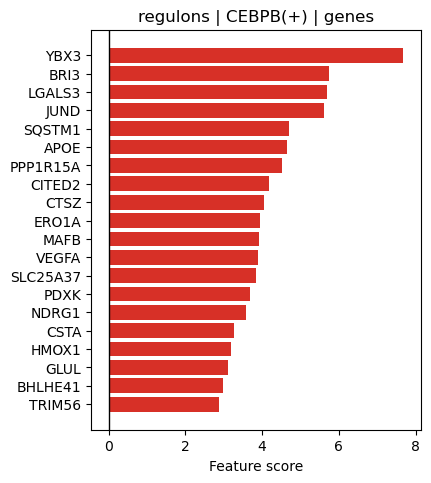

In [7]:
fig, ax = scfo.plot_modality_feature_top_items(
    ontology,
    modality="regulons",
    feature="CEBPB(+)",
    cell_type="Tumor",
    what="genes",
    n_pos=20,
    n_neg=0,
    figsize = (3.3, 4)
)

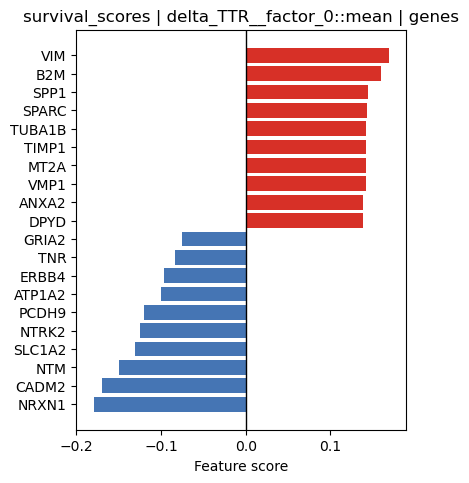

In [8]:
fig, ax = scfo.plot_modality_feature_top_items(
    ontology,
    modality="survival_scores",
    feature="delta_TTR__factor_0::mean",
    cell_type="Tumor",
    what="genes",
    n_pos=10,
    n_neg=10,
    figsize = (3.3, 4)
)

You can also plot the top factors enriched for a given modality by changing the `what` parameter to `'factors'`:

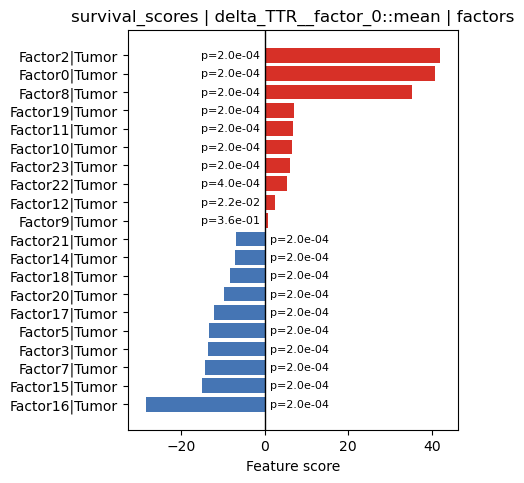

In [9]:
fig, ax = scfo.plot_modality_feature_top_items(
    ontology,
    modality="survival_scores",
    feature="delta_TTR__factor_0::mean",
    cell_type="Tumor",
    what="factors",
    n_pos=10,
    n_neg=10,
    figsize = (3.3, 4)
)

This same function can be used to query top-enriched factors for a specific modality in a cell type-agnostic manner:

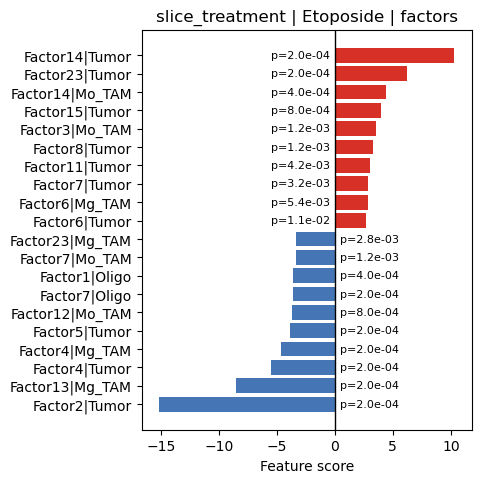

In [10]:
fig, ax = scfo.plot_modality_feature_top_items(
    ontology,
    modality="slice_treatment",
    feature="Etoposide",
    cell_type=None,
    what="factors",
    n_pos=10,
    n_neg=10,
    figsize = (3.3, 4)
)

Finally, to extract enrichment scores as a DataFrame for custom plotting:

In [11]:
mo_tam_scores = scfo.modality_scores_to_df(
    ontology=ontology, 
    modality='liana_ligand', 
    cell_types='Mo_TAM'
)

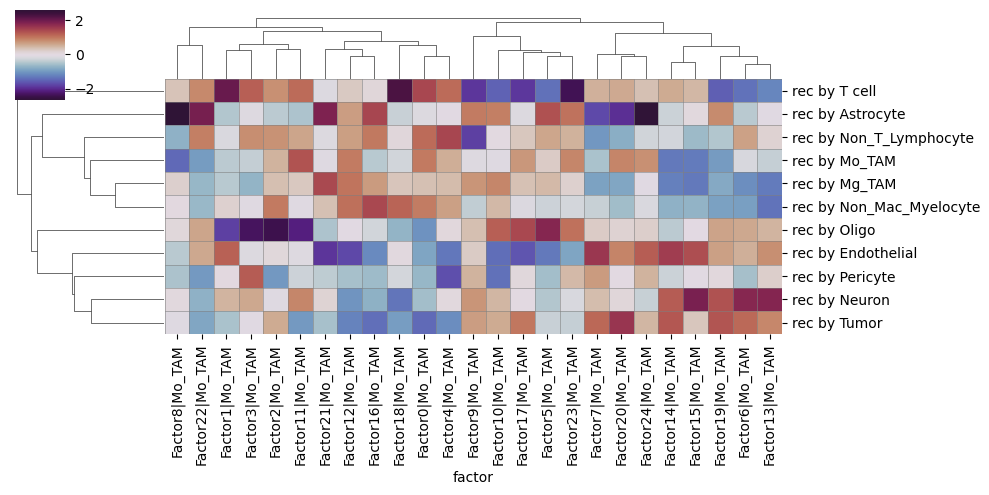

In [12]:
g = sns.clustermap(mo_tam_scores.T, z_score = 1, cmap = 'twilight_shifted', figsize = (10, 5))
ax = g.ax_heatmap
for x in range(mo_tam_scores.T.shape[1] + 1):  # columns
    ax.axvline(x, color='grey', linewidth=0.4)

for y in range(mo_tam_scores.T.shape[0] + 1):  # rows
    ax.axhline(y, color='grey', linewidth=0.4)

You can also extract DataFrames of feature loadings for custom plotting:

In [13]:
mo_tam_loadings = scfo.modality_feature_loadings_to_df(
    ontology=ontology, 
    modality='liana_receptor', 
    cell_types='Mo_TAM'
)

/var/folders/lk/rmp2brln64q4dhdslybx7s440000gn/T/ipykernel_98693/1036614976.py:6: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  g = sns.clustermap(mo_tam_loadings.loc[all_feat].T, cmap = 'inferno', figsize = (10, 5))


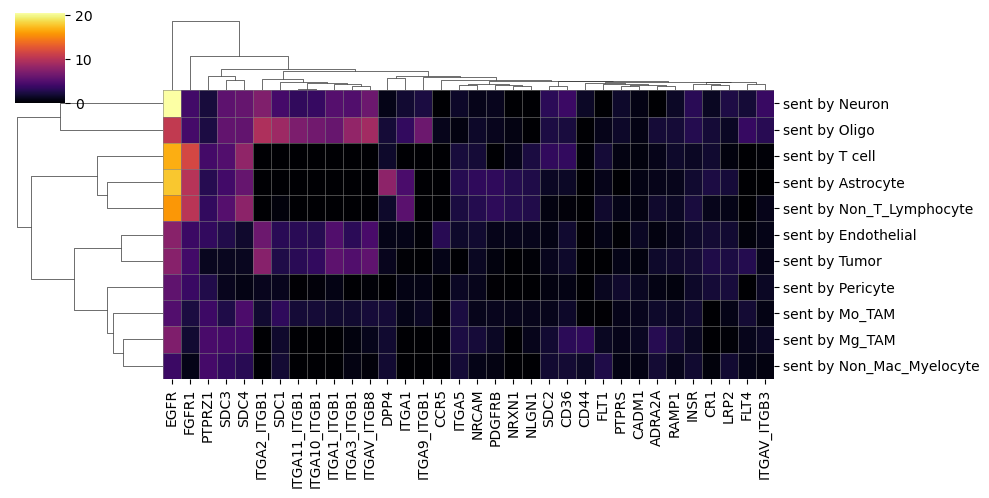

In [14]:
all_feat = set()
n_feat = 10
for col in mo_tam_loadings.columns:
    all_feat = all_feat | set(mo_tam_loadings[col].sort_values(ascending = False).head(n_feat).index)

g = sns.clustermap(mo_tam_loadings.loc[all_feat].T, cmap = 'inferno', figsize = (10, 5))
ax = g.ax_heatmap
for x in range(mo_tam_loadings.T.shape[1] + 1):  # columns
    ax.axvline(x, color='grey', linewidth=0.4)

for y in range(mo_tam_loadings.T.shape[0] + 1):  # rows
    ax.axhline(y, color='grey', linewidth=0.4)